In [ ]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [21]:
import os, glob, random, json, tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from collections import Counter

In [22]:
DATA_DIR = "/kaggle/input/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled"

IMG_SIZE = 128
BATCH_SIZE = 64
SEED = 42
MIN_IMAGES_PER_ID = 10
TOP_K = 200   # adjust 200–500 depending on GPU/time

random.seed(SEED)

# 1) scan identities
people = []
for person in os.listdir(DATA_DIR):
    pdir = os.path.join(DATA_DIR, person)
    if not os.path.isdir(pdir):
        continue
    imgs = glob.glob(os.path.join(pdir, "*.jpg")) + glob.glob(os.path.join(pdir, "*.png"))
    if len(imgs) >= MIN_IMAGES_PER_ID:
        people.append((person, len(imgs)))

people.sort(key=lambda x: x[1], reverse=True)
people = people[:TOP_K]

class_names = [p for p,_ in people]
class_to_idx = {c:i for i,c in enumerate(class_names)}
print("Classes kept:", len(class_names))
print("Top 5:", people[:5])

# 2+3) stratified split PER identity (ensures every class appears in train and val)
train_paths, train_labels = [], []
val_paths, val_labels = [], []

for person, _ in people:
    pdir = os.path.join(DATA_DIR, person)
    imgs = glob.glob(os.path.join(pdir, "*.jpg")) + glob.glob(os.path.join(pdir, "*.png"))
    random.shuffle(imgs)

    # 80/20 split within this identity
    n = len(imgs)
    n_train = int(0.8 * n)

    # enforce at least 1 image in val and at least 1 in train
    n_train = min(max(1, n_train), n - 1)

    tr = imgs[:n_train]
    va = imgs[n_train:]

    label = class_to_idx[person]
    train_paths.extend(tr)
    train_labels.extend([label] * len(tr))
    val_paths.extend(va)
    val_labels.extend([label] * len(va))

print("Train images:", len(train_paths), "Val images:", len(val_paths))

train_counts = Counter(train_labels)
val_counts = Counter(val_labels)

print("Min train imgs/class:", min(train_counts.values()))
print("Min val imgs/class:", min(val_counts.values()))
print("Classes missing in val:", sum(1 for c in range(len(class_names)) if c not in val_counts))

# 4) tf.data loader
def load_image(fp, y):
    img = tf.io.read_file(fp)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32)
    img = (img / 127.5) - 1.0  # [-1,1]
    return img, y

AUTOTUNE = tf.data.AUTOTUNE
train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_ds = train_ds.shuffle(2000, seed=SEED).map(load_image, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).prefetch(AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
val_ds = val_ds.map(load_image, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).prefetch(AUTOTUNE)

# Save mapping (so you can interpret predictions later)
OUT_DIR = "/kaggle/working/cnn_classifier"
os.makedirs(OUT_DIR, exist_ok=True)
with open(os.path.join(OUT_DIR, "class_names.json"), "w") as f:
    json.dump(class_names, f, indent=2)

NUM_CLASSES = len(class_names)

Classes kept: 158
Top 5: [('George_W_Bush', 530), ('Colin_Powell', 236), ('Tony_Blair', 144), ('Donald_Rumsfeld', 121), ('Gerhard_Schroeder', 109)]
Train images: 3397 Val images: 927
Min train imgs/class: 8
Min val imgs/class: 2
Classes missing in val: 0


In [23]:
augment = keras.Sequential([
    layers.RandomFlip("horizontal"),
], name="aug")

def conv_bn_relu(x, f, s=1, name=""):
    x = layers.Conv2D(f, 3, strides=s, padding="same", use_bias=False,
                      kernel_initializer="he_normal", name=name+"conv")(x)
    x = layers.BatchNormalization(name=name+"bn")(x)
    x = layers.ReLU(name=name+"relu")(x)
    return x

def build_plaincnn10(num_classes, embed_dim=256):
    inp = keras.Input((IMG_SIZE, IMG_SIZE, 3))
    x = augment(inp)

    stage_cfg = [(32,2),(64,2),(128,3),(256,3)]  # 10 conv layers total
    for si,(f,n) in enumerate(stage_cfg, start=1):
        for ci in range(1, n+1):
            x = conv_bn_relu(x, f, s=(2 if ci==1 else 1), name=f"s{si}_c{ci}_")

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(embed_dim, kernel_initializer="he_normal")(x)
    x = layers.ReLU()(x)
    x = layers.Dropout(0.2)(x)
    out = layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inp, out, name="PlainCNN10_Classifier")

model = build_plaincnn10(NUM_CLASSES, embed_dim=256)
model.compile(
    optimizer=keras.optimizers.Adam(3e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.summary()

Model: "PlainCNN10_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ aug (Sequential)                │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s1_c1_conv (Conv2D)             │ (None, 64, 64, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s1_c1_bn (BatchNormalization)   │ (None, 64, 64, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s1_c1_relu (ReLU)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s1_c2_conv (Conv2D)             │ (None, 64, 64, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s1_c2_bn (BatchNormalization)   │ (None, 64, 64, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s1_c2_relu (ReLU)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s2_c1_conv (Conv2D)             │ (None, 32, 32, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s2_c1_bn (BatchNormalization)   │ (None, 32, 32, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s2_c1_relu (ReLU)               │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s2_c2_conv (Conv2D)             │ (None, 32, 32, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s2_c2_bn (BatchNormalization)   │ (None, 32, 32, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s2_c2_relu (ReLU)               │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s3_c1_conv (Conv2D)             │ (None, 16, 16, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s3_c1_bn (BatchNormalization)   │ (None, 16, 16, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s3_c1_relu (ReLU)               │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s3_c2_conv (Conv2D)             │ (None, 16, 16, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s3_c2_bn (BatchNormalization)   │ (None, 16, 16, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s3_c2_relu (ReLU)               │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s3_c3_conv (Conv2D)             │ (None, 16, 16, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s3_c3_bn (BatchNormalization)   │ (None, 16, 16, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s3_c3_relu (ReLU)               │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s4_c1_conv (Conv2D)             │ (None, 8, 8, 256)      │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s4_c1_bn (BatchNormalization)   │ (None, 8, 8, 256)      │         1,02

 Total params: 2,020,350 (7.71 MB)

 Trainable params: 2,017,662 (7.70 MB)

 Non-trainable params: 2,688 (10.50 KB)

In [24]:
OUT_DIR = "/kaggle/working/cnn_classifier"
best_path = os.path.join(OUT_DIR, "best.weights.h5")

ckpt = keras.callbacks.ModelCheckpoint(
    best_path, monitor="val_accuracy", mode="max",
    save_best_only=True, save_weights_only=True, verbose=1
)

early = keras.callbacks.EarlyStopping(
    monitor="val_accuracy", mode="max", patience=7,
    restore_best_weights=True, verbose=1
)

hist = model.fit(train_ds, validation_data=val_ds, epochs=25, callbacks=[ckpt, early])

with open(os.path.join(OUT_DIR, "history.json"), "w") as f:
    json.dump(hist.history, f, indent=2)

print("✅ Saved best weights to:", best_path)

Epoch 1/25


I0000 00:00:1771321098.796723     131 service.cc:152] XLA service 0x7d6f14b28f50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771321098.796798     131 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0


 7/54 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.0020 - loss: 5.1880     

I0000 00:00:1771321105.436617     131 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.0662 - loss: 4.9308
Epoch 1: val_accuracy improved from -inf to 0.11435, saving model to /kaggle/working/cnn_classifier/best.weights.h5
54/54 ━━━━━━━━━━━━━━━━━━━━ 21s 179ms/step - accuracy: 0.0667 - loss: 4.9286 - val_accuracy: 0.1143 - val_loss: 4.7881
Epoch 2/25
52/54 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.1806 - loss: 4.1557
Epoch 2: val_accuracy improved from 0.11435 to 0.13053, saving model to /kaggle/working/cnn_classifier/best.weights.h5
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.1791 - loss: 4.1649 - val_accuracy: 0.1305 - val_loss: 4.3754
Epoch 3/25
52/54 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.2267 - loss: 3.7730
Epoch 3: val_accuracy improved from 0.13053 to 0.18015, saving model to /kaggle/working/cnn_classifier/best.weights.h5
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.2249 - loss: 3.7847 - val_accuracy: 0.1802 - val_loss: 4.0614
Epoch 4/25
53/54 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step 

In [25]:
model.load_weights("/kaggle/working/cnn_classifier/best.weights.h5")
print("Best weights loaded.")

Best weights loaded.


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


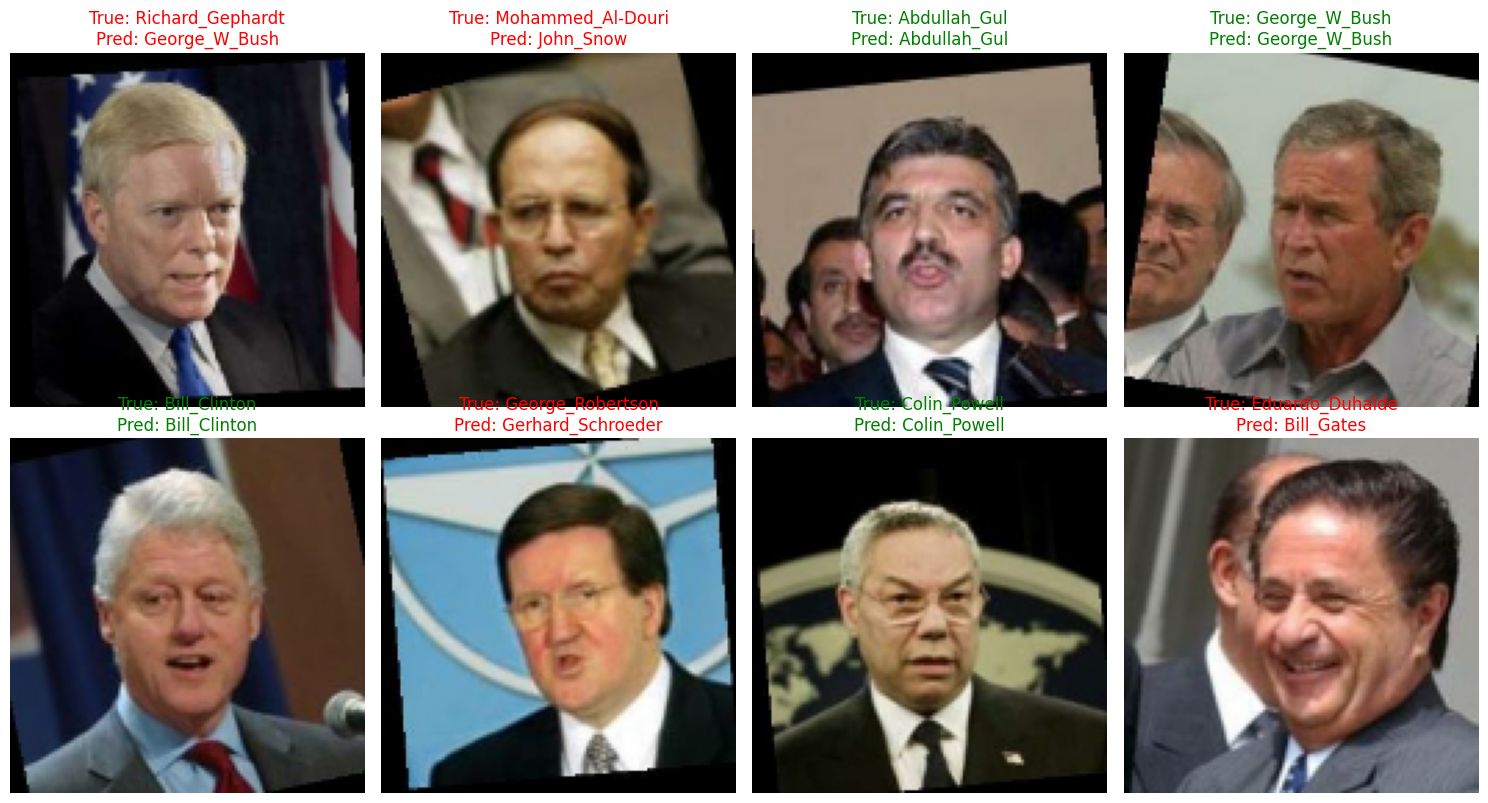

In [27]:
import numpy as np
import matplotlib.pyplot as plt

model.load_weights("/kaggle/working/cnn_classifier/best.weights.h5")

idxs = np.random.choice(len(val_paths), size=8, replace=False)

imgs = []
true_ids = []
for i in idxs:
    fp = val_paths[i]
    y = val_labels[i]

    img = tf.io.read_file(fp)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32)
    img = (img / 127.5) - 1.0

    imgs.append(img)
    true_ids.append(y)

imgs = tf.stack(imgs, axis=0)
probs = model.predict(imgs)
preds = np.argmax(probs, axis=1)

plt.figure(figsize=(15,8))
for k in range(8):
    plt.subplot(2,4,k+1)
    show = (imgs[k].numpy() + 1) / 2
    plt.imshow(show)
    plt.axis("off")

    t = class_names[true_ids[k]]
    p = class_names[preds[k]]
    color = "green" if t == p else "red"
    plt.title(f"True: {t}\nPred: {p}", color=color)

plt.tight_layout()
plt.show()